# Classification des défauts d’acier — LBP et SVM, version améliorée

**Groupe 2 · Reconnaissance de formes · UNIKIN**

Ouvrir ce notebook avec le noyau **unikin_ml**, puis exécuter les cellules dans l’ordre. Aucune installation ni mise à jour de bibliothèque n’est effectuée. Le dossier attendu est `C:\Master_2\RDF\NEU-CLS-64` ; un ancien chemin est accepté s’il est le seul disponible.

Nous comparons LBP invariant (10 fréquences), LBP non invariant (59 fréquences) et cinq propriétés GLCM (20 valeurs), avec un SVM RBF. Pour chaque descripteur : sans pondération, pondération équilibrée, ou répétition des exemples de rouille dans l’apprentissage jusqu’à l’effectif de la plus grande classe. Ce dernier traitement n’invente aucune nouvelle image.

**Protocole fixé avant les résultats :** mêmes partitions que le notebook fourni (64 % apprentissage, 16 % validation, 20 % test). Cinq plis stratifiés sur l’apprentissage sélectionnent les hyperparamètres et la stratégie. Le modèle principal reste un modèle **LBP**, conformément au sujet ; GLCM sert de comparaison. La validation fixe mesure les performances des neuf candidats retenus en validation croisée, sans changer automatiquement le choix. Le test n’est évalué que pour le modèle LBP retenu.

Le test a déjà été consulté dans les expériences précédentes : ses nouveaux scores ne constituent pas une évaluation sur un corpus inédit. Les doublons exacts sont retirés ; les quasi-doublons et l’origine physique des imagettes ne sont pas résolus par ce protocole. « Améliorée » décrit la méthode de travail, pas une garantie de meilleur score.

Les calculs sont sauvegardés par configuration : une interruption permet de reprendre sans refaire les configurations terminées. La fenêtre de sélection d’image est facultative et ne bloque pas « Tout exécuter ».


## 1. Environnement et chemins
Cette cellule vérifie les imports avant tout traitement. Seule la variable `DOSSIER` doit être adaptée si tes images se trouvent ailleurs.


In [1]:
from pathlib import Path
from collections import Counter
from datetime import datetime
from importlib.metadata import version
import sys, json, hashlib, shutil, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import joblib
from IPython.display import display
from skimage.feature import local_binary_pattern, graycomatrix, graycoprops
from sklearn.model_selection import train_test_split, StratifiedKFold, ParameterGrid
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay)

DOSSIER = Path(r"C:\Master_2\RDF\NEU-CLS-64")
if not DOSSIER.is_dir():
    candidats = [Path.cwd() / "NEU-CLS-64",
                 Path(r"C:\Users\user\Desktop\RDF\NEU-CLS-64")]
    candidats = list(dict.fromkeys(p.resolve() for p in candidats if p.is_dir()))
    if len(candidats) == 1:
        DOSSIER = candidats[0]
    else:
        raise FileNotFoundError("Renseigner DOSSIER avec le chemin exact de NEU-CLS-64.")
DOSSIER = DOSSIER.resolve()
GRAINE = 42
P, R = 8, 1
N_PLIS = 5
EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
NOMS_CLASSES = {
    "cr": "Fissures en réseau", "gg": "Cavités", "in": "Inclusions",
    "pa": "Plaques et taches étendues", "ps": "Surface piquée",
    "rp": "Rouille", "rs": "Calamine incrustée", "sc": "Rayures",
    "sp": "Taches d’huile"
}
CLASSES = sorted(NOMS_CLASSES)
def nom_classe(c):
    return f"{NOMS_CLASSES[str(c)]} ({c})"
VERSIONS = {p: version(p) for p in
            ["numpy", "scipy", "scikit-learn", "scikit-image", "Pillow", "pandas", "matplotlib", "joblib"]}
print("Python :", sys.executable)
print("Version :", sys.version.split()[0])
print("Données :", DOSSIER)
display(pd.Series(VERSIONS, name="Version"))
print("Imports réussis. Aucune modification de l’environnement.")

SORTIE_RACINE = DOSSIER.parent / "resultats_TP_ameliore"
SORTIE_RACINE.mkdir(exist_ok=True)
def ecrire_json(chemin, objet):
    chemin = Path(chemin)
    temporaire = chemin.with_suffix(chemin.suffix + ".tmp")
    temporaire.write_text(json.dumps(objet, ensure_ascii=False, indent=2), encoding="utf-8")
    temporaire.replace(chemin)

def lire_gris(chemin):
    with Image.open(chemin) as im:
        a = np.array(im.convert("L"), dtype=np.uint8)
    if a.ndim != 2 or min(a.shape) <= 2 * R:
        raise ValueError(f"Image invalide ou trop petite : {chemin}, {a.shape}")
    return a

def empreinte_pixels(a):
    return hashlib.sha256(str(a.shape).encode() + a.tobytes()).hexdigest()


Python : C:\Users\user\anaconda3\envs\unikin_ml\python.exe
Version : 3.12.13
Données : C:\Master_2\RDF\NEU-CLS-64


numpy            2.2.6
scipy           1.18.0
scikit-learn     1.9.0
scikit-image    0.26.0
Pillow          12.3.0
pandas           3.0.5
matplotlib      3.11.1
joblib           1.5.3
Name: Version, dtype: str

Imports réussis. Aucune modification de l’environnement.


## 2. Inventaire, doublons et conservation des partitions
La procédure reprend exactement le tri, le hachage et les deux séparations du notebook initial. Si une sauvegarde de l’ancienne expérience existe, les empreintes des trois ensembles sont comparées. Un changement du corpus interrompt une reprise existante.


In [2]:
fichiers = sorted(f for f in DOSSIER.rglob("*")
                  if f.is_file() and f.suffix.lower() in EXTENSIONS)
if not fichiers or any(f.parent.parent != DOSSIER for f in fichiers):
    raise ValueError("Structure attendue : NEU-CLS-64/code_classe/image.")
y = np.array([f.parent.name for f in fichiers])
if set(y) != set(CLASSES):
    raise ValueError(f"Les neuf classes attendues ne correspondent pas : {sorted(set(y))}")
chemins_source = np.array([str(f) for f in fichiers])
empreintes_images, indices_uniques, doublons_details = [], [], []
vus = {}
for i, f in enumerate(fichiers):
    h = empreinte_pixels(lire_gris(f))
    empreintes_images.append(h)
    if h in vus:
        j = vus[h]
        if y[i] != y[j]:
            raise ValueError(f"Même image avec deux étiquettes : {fichiers[j]} et {f}")
        doublons_details.append({"ecartee": str(f), "conservee": str(fichiers[j]), "empreinte": h})
    else:
        vus[h] = i
        indices_uniques.append(i)
empreintes_images = np.array(empreintes_images)
indices_uniques = np.array(indices_uniques, dtype=int)
idx_developpement, idx_test = train_test_split(indices_uniques, test_size=.20,
    random_state=GRAINE, stratify=y[indices_uniques])
idx_train, idx_val = train_test_split(idx_developpement, test_size=.20,
    random_state=GRAINE, stratify=y[idx_developpement])
PARTITIONS = {"train": idx_train, "validation": idx_val, "test": idx_test}
for a, b in [(idx_train, idx_val), (idx_train, idx_test), (idx_val, idx_test)]:
    assert set(empreintes_images[a]).isdisjoint(empreintes_images[b])
assert min(Counter(y[idx_train]).values()) >= N_PLIS

# Vérification contre les anciennes sauvegardes, si présentes.
anciennes = sorted(DOSSIER.parent.glob("dataset_SVM_*/resultats/donnees_experience.npz"))
for archive in anciennes:
    with np.load(archive, allow_pickle=False) as ancien:
        if not {"empreintes", "idx_train", "idx_val", "idx_test"}.issubset(ancien.files):
            continue
        for cle, idx in [("idx_train", idx_train), ("idx_val", idx_val), ("idx_test", idx_test)]:
            if set(ancien["empreintes"][ancien[cle]]) != set(empreintes_images[idx]):
                raise ValueError(f"Partitions différentes de {archive}. Vérifier le corpus avant de poursuivre.")
print("Anciennes archives vérifiées :", len(anciennes))

identite = [{"fichier": str(f.relative_to(DOSSIER)), "classe": str(y[i]),
             "sha256": str(empreintes_images[i])} for i, f in enumerate(fichiers)]
signature_corpus = hashlib.sha256(json.dumps(identite, sort_keys=True).encode()).hexdigest()
manifest_path = SORTIE_RACINE / "manifest_partitions.json"
manifest = {"signature_corpus": signature_corpus, "graine": GRAINE,
            "partitions": {k: v.tolist() for k,v in PARTITIONS.items()}, "images": identite}
if manifest_path.exists():
    precedent = json.loads(manifest_path.read_text(encoding="utf-8"))
    if precedent != manifest:
        raise ValueError("Le corpus ou la séparation diffère de la reprise enregistrée. Ne pas mélanger les expériences.")
else:
    ecrire_json(manifest_path, manifest)

effectifs = pd.DataFrame({"initial": pd.Series(Counter(y)),
    **{k: pd.Series(Counter(y[v])) for k,v in PARTITIONS.items()}}).reindex(CLASSES).fillna(0).astype(int)
effectifs["total_unique"] = effectifs[["train", "validation", "test"]].sum(axis=1)
display(effectifs)
print("Doublons exacts écartés :", len(doublons_details))
print("Images uniques :", len(indices_uniques))
effectifs.to_csv(SORTIE_RACINE / "effectifs.csv")
pd.DataFrame(doublons_details).to_csv(SORTIE_RACINE / "doublons_ecartes.csv", index=False)


Anciennes archives vérifiées : 1


,initial,train,validation,test,total_unique
cr,1210,774,194,242,1210
gg,296,190,47,59,296
in,775,496,124,155,775
pa,1148,731,183,229,1143
ps,797,510,128,159,797
rp,200,127,32,39,198
rs,1589,1017,254,318,1589
sc,773,495,123,155,773
sp,438,280,70,88,438


Doublons exacts écartés : 7
Images uniques : 7219


## 3. Dossiers séparés et exemples
Les images originales restent en place. Les copies existantes sont vérifiées et réutilisées ; les suréchantillons ne sont jamais copiés dans ces dossiers.


Dossiers prêts : C:\Master_2\RDF\dataset_SVM_ameliore


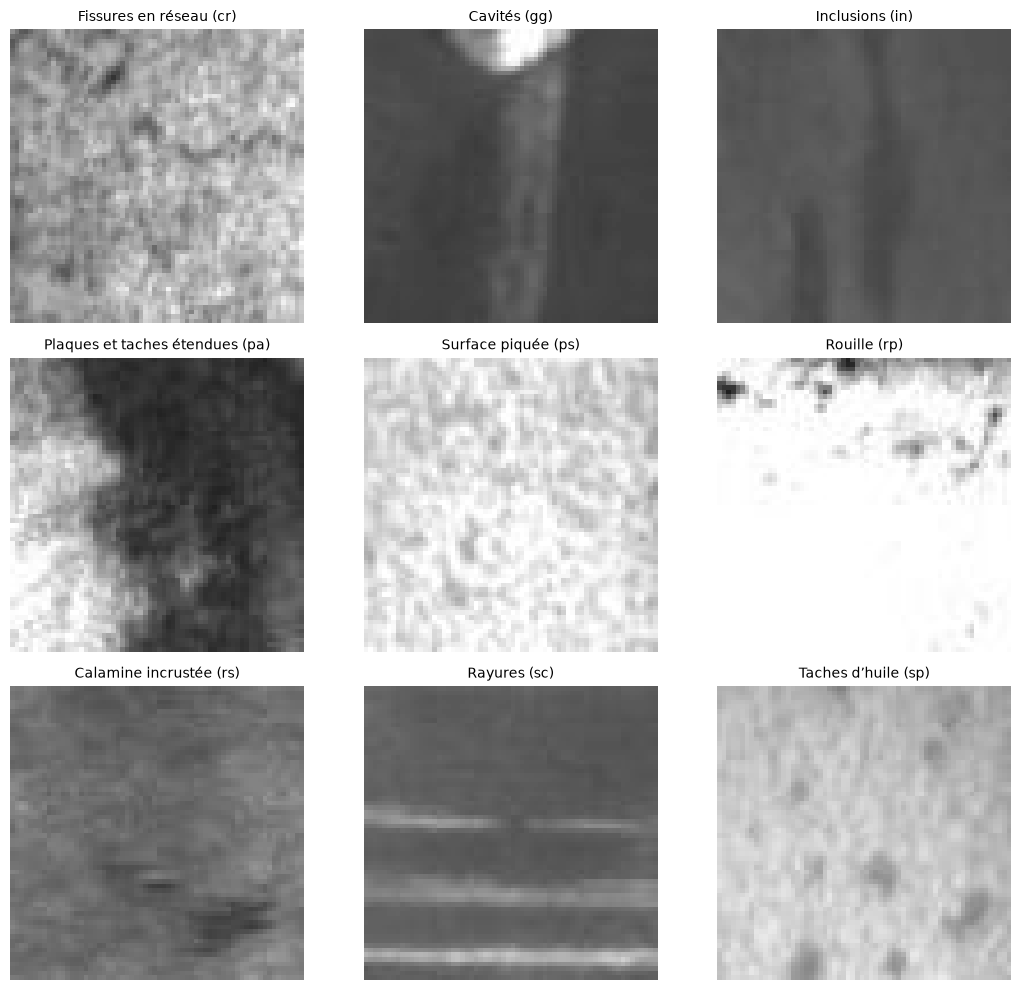

In [3]:
DOSSIER_SPLIT = DOSSIER.parent / "dataset_SVM_ameliore"
chemins = chemins_source.copy()
# Utiliser une liste : les chemins des copies peuvent être plus longs que ceux des sources.
chemins = list(chemins)
for ensemble, indices in PARTITIONS.items():
    for i in indices:
        source = Path(chemins_source[i])
        cible = DOSSIER_SPLIT / ensemble / str(y[i]) / source.name
        cible.parent.mkdir(parents=True, exist_ok=True)
        if not cible.exists():
            shutil.copy2(source, cible)
        if empreinte_pixels(lire_gris(cible)) != empreintes_images[i]:
            raise ValueError(f"Copie modifiée : {cible}")
        chemins[i] = str(cible)
chemins = np.array(chemins)
print("Dossiers prêts :", DOSSIER_SPLIT)

fig, axes = plt.subplots(3, 3, figsize=(11, 10))
for ax, c in zip(axes.ravel(), CLASSES):
    i = next(i for i in idx_train if y[i] == c)
    ax.imshow(lire_gris(chemins[i]), cmap="gray", vmin=0, vmax=255)
    ax.set_title(nom_classe(c), fontsize=10)
    ax.axis("off")
fig.tight_layout()
fig.savefig(SORTIE_RACINE / "exemples_textures.jpeg", dpi=180, bbox_inches="tight")
plt.show()


## 4. LBP manuel : compréhension et contrôle
Pour chaque centre, on prélève huit voisins sur un cercle de rayon 1. Les points entre pixels sont interpolés bilinéairement. Chaque comparaison voisin ≥ centre produit un bit ; les poids sont 1, 2, 4, …, 128.

Le regroupement `uniform` compte les bits à 1 lorsque le motif comporte au plus deux transitions circulaires ; sinon il attribue le code 9. Il produit donc 10 fréquences. La variante `nri_uniform` distingue aussi l’orientation et produit 59 fréquences.

L’implémentation pédagogique ci-dessous est comparée à `default` et à `uniform`, sur plusieurs images artificielles et une image d’apprentissage de chaque classe. Les déplacements sont arrondis à cinq décimales, convention de scikit-image. Les bords sont exclus. L’accord affiché concerne seulement les cas vérifiés, pas toutes les images possibles. Les expériences emploient la bibliothèque optimisée.


In [4]:
def lbp_manuel(image, P=8, R=1):
    if not isinstance(P, int) or not 1 <= P <= 16 or R <= 0:
        raise ValueError("P entier entre 1 et 16 ; R strictement positif.")
    a = np.asarray(image, dtype=np.float64)
    b = int(np.ceil(R))
    if a.ndim != 2 or min(a.shape) <= 2*b:
        raise ValueError("Image trop petite ou non bidimensionnelle.")
    yy, xx = np.mgrid[b:a.shape[0]-b, b:a.shape[1]-b]
    centre = a[yy, xx]
    bits = []
    brut = np.zeros(centre.shape, dtype=np.uint32)
    for p in range(P):
        dy = np.round(-R * np.sin(2*np.pi*p/P), 5)
        dx = np.round( R * np.cos(2*np.pi*p/P), 5)
        yf, xf = yy + dy, xx + dx
        y0, x0 = np.floor(yf).astype(int), np.floor(xf).astype(int)
        y1, x1 = np.ceil(yf).astype(int), np.ceil(xf).astype(int)
        ty, tx = yf-y0, xf-x0
        haut = (1-tx)*a[y0,x0] + tx*a[y0,x1]
        bas = (1-tx)*a[y1,x0] + tx*a[y1,x1]
        voisin = (1-ty)*haut + ty*bas
        bit = voisin >= centre
        bits.append(bit)
        brut += bit.astype(np.uint32) * (1 << p)
    bits = np.stack(bits).astype(np.uint8)
    transitions = np.count_nonzero(bits != np.roll(bits, -1, axis=0), axis=0)
    uniforme = np.where(transitions <= 2, bits.sum(axis=0), P+1).astype(np.uint8)
    return brut, uniforme

rng = np.random.default_rng(GRAINE)
cas = {"constant": np.full((24,24), 128, dtype=np.uint8),
       "rampe": np.tile(np.arange(24, dtype=np.uint8), (24,1)),
       "damier": ((np.indices((24,24)).sum(axis=0)%2)*255).astype(np.uint8),
       "aleatoire": rng.integers(0,256,(32,32),dtype=np.uint8)}
for c in CLASSES:
    i = next(i for i in idx_train if y[i] == c)
    cas[c] = lire_gris(chemins[i])
controles = []
for nom, a in cas.items():
    brut, uniforme = lbp_manuel(a, P, R)
    for methode, manuel in [("default", brut), ("uniform", uniforme)]:
        ref = local_binary_pattern(a, P, R, method=methode)[R:-R,R:-R]
        controles.append({"image":nom,"methode":methode,
                         "pixels":int(ref.size),"differences":int(np.count_nonzero(manuel != ref))})
controle_lbp = pd.DataFrame(controles)
display(controle_lbp)
controle_lbp.to_csv(SORTIE_RACINE / "verification_lbp_manuel.csv", index=False)
if controle_lbp["differences"].sum():
    warnings.warn("Des différences numériques existent : ne pas annoncer une équivalence exacte. Le modèle utilise scikit-image.")
else:
    print("Accord exact sur tous les cas vérifiés, hors bordure.")


,image,methode,pixels,differences
0,constant,default,484,0
1,constant,uniform,484,0
2,rampe,default,484,0
3,rampe,uniform,484,0
4,damier,default,484,0
5,damier,uniform,484,0
6,aleatoire,default,900,0
7,aleatoire,uniform,900,0
8,cr,default,3844,0
9,cr,uniform,3844,0


Accord exact sur tous les cas vérifiés, hors bordure.


## 5. Extraction des trois descripteurs
Les images restent en niveaux de gris et à leur taille d’origine. Les histogrammes LBP excluent une bordure de 1 pixel et somment à 1. GLCM utilise 64 niveaux, une distance de 1 pixel et quatre angles. L’extraction ne dépend d’aucune étiquette ; la standardisation sera ajustée uniquement pendant l’apprentissage.


Extraction : 500/7219 — 4 s
Extraction : 1000/7219 — 8 s
Extraction : 1500/7219 — 11 s
Extraction : 2000/7219 — 16 s
Extraction : 2500/7219 — 20 s
Extraction : 3000/7219 — 24 s
Extraction : 3500/7219 — 27 s
Extraction : 4000/7219 — 30 s
Extraction : 4500/7219 — 33 s
Extraction : 5000/7219 — 37 s
Extraction : 5500/7219 — 40 s
Extraction : 6000/7219 — 43 s
Extraction : 6500/7219 — 47 s
Extraction : 7000/7219 — 50 s
lbp_uniform (7226, 10)
lbp_nri_uniform (7226, 59)
glcm (7226, 20)


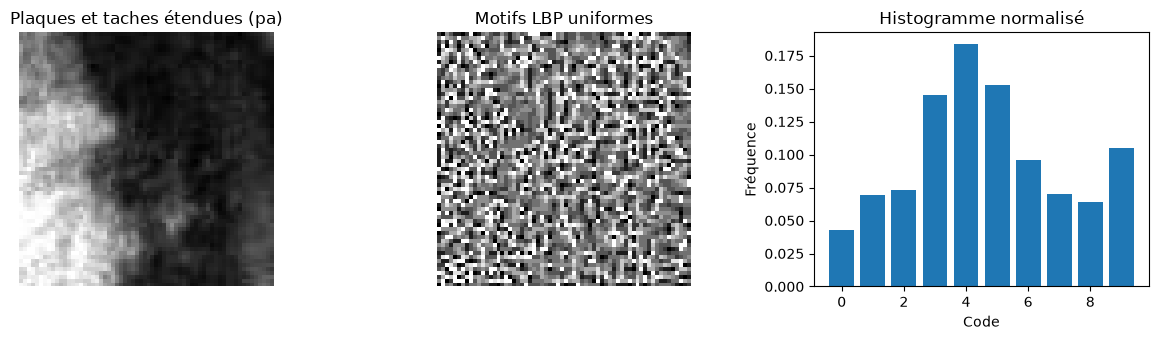

In [5]:
GLCM_NIVEAUX = 64
GLCM_ANGLES = [0, np.pi/4, np.pi/2, 3*np.pi/4]
GLCM_PROPS = ["contrast", "dissimilarity", "homogeneity", "energy", "correlation"]
DESCRIPTEURS = {"lbp_uniform": 10, "lbp_nri_uniform": 59, "glcm": 20}

def extraire_image(a, nom):
    if nom.startswith("lbp_"):
        methode = nom[len("lbp_"):]
        codes = local_binary_pattern(a, P, R, method=methode)[R:-R,R:-R]
        n = DESCRIPTEURS[nom]
        hist = np.bincount(codes.astype(int).ravel(), minlength=n).astype(float)
        if len(hist) != n or hist.sum() == 0:
            raise ValueError("Codes LBP hors intervalle ou histogramme vide.")
        v = hist / hist.sum()
    elif nom == "glcm":
        q = (a.astype(np.uint16) * GLCM_NIVEAUX // 256).astype(np.uint8)
        g = graycomatrix(q, distances=[1], angles=GLCM_ANGLES,
                        levels=GLCM_NIVEAUX, symmetric=True, normed=True)
        v = np.concatenate([graycoprops(g, p).ravel() for p in GLCM_PROPS])
    else:
        raise ValueError(nom)
    if v.shape != (DESCRIPTEURS[nom],) or not np.isfinite(v).all():
        raise ValueError(f"Descripteur invalide : {nom}")
    return v

configuration = {"version_protocole": "2.0", "corpus": signature_corpus,
    "versions": VERSIONS, "P": P, "R": R, "glcm_niveaux": GLCM_NIVEAUX,
    "glcm_angles": GLCM_ANGLES, "glcm_proprietes": GLCM_PROPS,
    "graine": GRAINE, "plis": N_PLIS}
signature = hashlib.sha256(json.dumps(configuration, sort_keys=True).encode()).hexdigest()[:16]
SORTIE = SORTIE_RACINE / signature
SORTIE.mkdir(exist_ok=True)
ecrire_json(SORTIE / "configuration.json", configuration)
cache = SORTIE / "caracteristiques.npz"
if cache.exists():
    with np.load(cache, allow_pickle=False) as z:
        features = {nom:z[nom].copy() for nom in DESCRIPTEURS}
    print("Caractéristiques rechargées.")
else:
    features = {nom:np.full((len(fichiers),d), np.nan) for nom,d in DESCRIPTEURS.items()}
    t0 = time.perf_counter()
    for numero,i in enumerate(indices_uniques,1):
        a = lire_gris(chemins[i])
        for nom in DESCRIPTEURS:
            features[nom][i] = extraire_image(a,nom)
        if numero % 500 == 0:
            print(f"Extraction : {numero}/{len(indices_uniques)} — {time.perf_counter()-t0:.0f} s", flush=True)
    # Les doublons exclus gardent la même description ; aucun ne participe aux partitions.
    for i in range(len(fichiers)):
        if np.isnan(features["lbp_uniform"][i]).any():
            j = vus[empreintes_images[i]]
            for nom in DESCRIPTEURS:
                features[nom][i] = features[nom][j]
    np.savez_compressed(cache, **features)
for nom,d in DESCRIPTEURS.items():
    assert features[nom].shape == (len(fichiers),d)
    assert np.isfinite(features[nom]).all()
    if nom.startswith("lbp"):
        assert np.allclose(features[nom].sum(axis=1),1)
    print(nom, features[nom].shape)

i = idx_train[0]
a = lire_gris(chemins[i])
fig,ax = plt.subplots(1,3,figsize=(12,3.5))
ax[0].imshow(a,cmap="gray"); ax[0].set_title(nom_classe(y[i])); ax[0].axis("off")
ax[1].imshow(local_binary_pattern(a,P,R,"uniform"),cmap="gray")
ax[1].set_title("Motifs LBP uniformes"); ax[1].axis("off")
ax[2].bar(range(10),features["lbp_uniform"][i]); ax[2].set_title("Histogramme normalisé")
ax[2].set_xlabel("Code"); ax[2].set_ylabel("Fréquence")
fig.tight_layout(); fig.savefig(SORTIE / "lbp_histogramme.jpeg",dpi=180,bbox_inches="tight")
plt.show()


## 6. Apprentissage : cinq plis et trois traitements du déséquilibre

Chaque configuration est évaluée sur **les mêmes cinq plis**. Le F1-macro moyen sert au classement ; l’écart-type décrit les variations entre plis, sans être une preuve de significativité.

- `aucun` : données d’apprentissage inchangées, poids uniformes.
- `balanced` : poids inversement proportionnels aux effectifs de chaque classe dans l’apprentissage du pli.
- `sur_rp` : répétition aléatoire, avec remise, des images `rp` de l’apprentissage du pli jusqu’à l’effectif de sa plus grande classe. La partie évaluée du pli reste intacte. Le normaliseur est ajusté sur ce seul apprentissage rééchantillonné.

Grille commune : C ∈ {0,1 ; 1 ; 10 ; 100}, gamma ∈ {scale ; 0,01 ; 1}. Au total **108 configurations × 5 plis = 540 ajustements SVM**, puis neuf ajustements pour la validation fixe. Le calcul peut être long. Les configurations terminées sont sauvegardées et réutilisées à la reprise. Aucun paquet supplémentaire n’est nécessaire.


In [6]:
STRATEGIES = ["aucun", "balanced", "sur_rp"]
GRILLE = list(ParameterGrid({"C":[0.1,1,10,100], "gamma":["scale",0.01,1]}))
plis = list(StratifiedKFold(n_splits=N_PLIS, shuffle=True, random_state=GRAINE)
            .split(np.zeros(len(idx_train)), y[idx_train]))
np.savez_compressed(SORTIE / "partitions_et_plis.npz", idx_train=idx_train,
    idx_val=idx_val, idx_test=idx_test, y=y, empreintes=empreintes_images,
    chemins=chemins, chemins_source=chemins_source,
    **{f"pli_{k}_train":idx_train[a] for k,(a,b) in enumerate(plis)},
    **{f"pli_{k}_evaluation":idx_train[b] for k,(a,b) in enumerate(plis)})

def indices_apprentissage(labels, strategie, graine):
    indices = np.arange(len(labels))
    if strategie == "sur_rp":
        rares = indices[np.asarray(labels) == "rp"]
        if not len(rares):
            raise ValueError("Rouille absente de cet apprentissage.")
        cible = max(Counter(labels).values())
        rng = np.random.default_rng(graine)
        extra = rng.choice(rares, size=cible-len(rares), replace=True)
        indices = np.concatenate([indices,extra])
        rng.shuffle(indices)
    elif strategie not in ["aucun","balanced"]:
        raise ValueError(strategie)
    return indices

def entrainer(Xa, ya, strategie, params, graine):
    selection = indices_apprentissage(ya,strategie,graine)
    pipeline = Pipeline([("normalisation",StandardScaler()),
        ("svm",SVC(kernel="rbf", C=params["C"], gamma=params["gamma"],
                   class_weight="balanced" if strategie=="balanced" else None,
                   cache_size=256, random_state=GRAINE))])
    pipeline.fit(Xa[selection],ya[selection])
    return pipeline

def mesures_prediction(vrai, pred):
    rapport = classification_report(vrai,pred,labels=CLASSES,output_dict=True,zero_division=0)
    return {"accuracy":float(accuracy_score(vrai,pred)),
        "balanced_accuracy":float(balanced_accuracy_score(vrai,pred)),
        "f1_macro":float(f1_score(vrai,pred,labels=CLASSES,average="macro",zero_division=0)),
        "rappel_rp":float(rapport["rp"]["recall"]), "f1_rp":float(rapport["rp"]["f1-score"])}

repertoire_cv = SORTIE / "cache_cv"
repertoire_cv.mkdir(exist_ok=True)
resultats_cv = []
t0 = time.perf_counter()
numero = 0
for desc in DESCRIPTEURS:
    Xa,ya = features[desc][idx_train],y[idx_train]
    for strategie in STRATEGIES:
        for params in GRILLE:
            numero += 1
            ident = {"descripteur":desc,"strategie":strategie,"params":params}
            cle = hashlib.sha256(json.dumps(ident,sort_keys=True).encode()).hexdigest()[:16]
            fichier_cache = repertoire_cv / f"{cle}.json"
            if fichier_cache.exists():
                resultat = json.loads(fichier_cache.read_text(encoding="utf-8"))
                assert all(resultat[k]==v for k,v in ident.items())
            else:
                scores = []
                for k,(appr,evaluation) in enumerate(plis):
                    mdl = entrainer(Xa[appr],ya[appr],strategie,params,GRAINE+k)
                    scores.append(mesures_prediction(ya[evaluation],mdl.predict(Xa[evaluation])))
                resultat = {**ident,"plis":scores,
                    **{f"moyenne_{m}":float(np.mean([s[m] for s in scores])) for m in scores[0]},
                    "ecart_type_f1":float(np.std([s["f1_macro"] for s in scores],ddof=1))}
                ecrire_json(fichier_cache,resultat)
            resultats_cv.append(resultat)
            print(f"[{numero}/108] {desc} / {strategie} / {params} : "
                  f"F1={resultat['moyenne_f1_macro']:.4f} ± {resultat['ecart_type_f1']:.4f}", flush=True)
cv_table = pd.DataFrame([{k:v for k,v in r.items() if k!="plis"} for r in resultats_cv])
cv_table.to_csv(SORTIE / "validation_croisee_complete.csv",index=False)
print(f"Comparaison terminée en {(time.perf_counter()-t0)/60:.1f} min pour cette exécution.")
display(cv_table.sort_values("moyenne_f1_macro",ascending=False).head(12))


[1/108] lbp_uniform / aucun / {'C': 0.1, 'gamma': 'scale'} : F1=0.5756 ± 0.0140
[2/108] lbp_uniform / aucun / {'C': 0.1, 'gamma': 0.01} : F1=0.5214 ± 0.0039
[3/108] lbp_uniform / aucun / {'C': 0.1, 'gamma': 1} : F1=0.4877 ± 0.0053
[4/108] lbp_uniform / aucun / {'C': 1, 'gamma': 'scale'} : F1=0.6643 ± 0.0171
[5/108] lbp_uniform / aucun / {'C': 1, 'gamma': 0.01} : F1=0.6007 ± 0.0139
[6/108] lbp_uniform / aucun / {'C': 1, 'gamma': 1} : F1=0.6497 ± 0.0114
[7/108] lbp_uniform / aucun / {'C': 10, 'gamma': 'scale'} : F1=0.7043 ± 0.0135
[8/108] lbp_uniform / aucun / {'C': 10, 'gamma': 0.01} : F1=0.6705 ± 0.0154
[9/108] lbp_uniform / aucun / {'C': 10, 'gamma': 1} : F1=0.6538 ± 0.0193
[10/108] lbp_uniform / aucun / {'C': 100, 'gamma': 'scale'} : F1=0.7010 ± 0.0193
[11/108] lbp_uniform / aucun / {'C': 100, 'gamma': 0.01} : F1=0.6888 ± 0.0180
[12/108] lbp_uniform / aucun / {'C': 100, 'gamma': 1} : F1=0.6367 ± 0.0186
[13/108] lbp_uniform / balanced / {'C': 0.1, 'gamma': 'scale'} : F1=0.6566 ± 0.012

[107/108] glcm / sur_rp / {'C': 100, 'gamma': 0.01} : F1=0.8231 ± 0.0045
[108/108] glcm / sur_rp / {'C': 100, 'gamma': 1} : F1=0.8193 ± 0.0164
Comparaison terminée en 10.3 min pour cette exécution.


,descripteur,strategie,params,moyenne_accuracy,moyenne_balanced_accuracy,moyenne_f1_macro,moyenne_rappel_rp,moyenne_f1_rp,ecart_type_f1
93,glcm,balanced,"{'C': 100, 'gamma': 'scale'}",0.917316,0.874810,0.861193,0.623692,0.488747,0.016215
81,glcm,aucun,"{'C': 100, 'gamma': 'scale'}",0.928571,0.846036,0.858548,0.340308,0.447420,0.025687
105,glcm,sur_rp,"{'C': 100, 'gamma': 'scale'}",0.914502,0.867366,0.857969,0.709538,0.508655,0.012179
94,glcm,balanced,"{'C': 100, 'gamma': 0.01}",0.896753,0.860508,0.838310,0.676923,0.506868,0.019419
90,glcm,balanced,"{'C': 10, 'gamma': 'scale'}",0.894372,0.848905,0.831813,0.614462,0.460773,0.017166
82,glcm,aucun,"{'C': 100, 'gamma': 0.01}",0.912987,0.812194,0.828811,0.284923,0.413915,0.010566
80,glcm,aucun,"{'C': 10, 'gamma': 1}",0.908225,0.816712,0.824126,0.268615,0.343684,0.014312
106,glcm,sur_rp,"{'C': 100, 'gamma': 0.01}",0.890693,0.834524,0.823085,0.780000,0.487051,0.004527
104,glcm,sur_rp,"{'C': 10, 'gamma': 1}",0.899567,0.817121,0.820046,0.354769,0.348212,0.011494
78,glcm,aucun,"{'C': 10, 'gamma': 'scale'}",0.908225,0.802863,0.819918,0.268923,0.403487,0.007036


## 7. Candidats retenus et validation fixe
Une configuration par couple descripteur/stratégie est retenue par le F1-macro moyen des cinq plis. En cas d’égalité exacte : écart-type plus faible, puis C plus petit, puis ordre de la grille. Le modèle principal est le meilleur de ces candidats **LBP**, toujours selon les cinq plis. GLCM est un point de comparaison.

Les neuf candidats apprennent sur le train entier et sont évalués sur la validation fixe. Leurs scores par classe permettent de comparer les pondérations et le suréchantillonnage. Le modèle sélectionné reste appris sur train seul ; aucun réentraînement sur validation ni choix à partir du test n’est effectué. Cette règle permet de garder un rôle distinct à chacun des trois dossiers.


,descripteur,strategie,f1_cv,ecart_type_cv,validation_accuracy,validation_balanced_accuracy,validation_f1_macro,validation_rappel_rp,validation_f1_rp,params,modele_principal
0,lbp_uniform,aucun,0.704273,0.013504,0.830303,0.719659,0.725093,0.03125,0.060606,"{'C': 10, 'gamma': 'scale'}",False
1,lbp_uniform,balanced,0.713065,0.013571,0.787013,0.724523,0.713785,0.37500,0.226415,"{'C': 100, 'gamma': 0.01}",False
2,lbp_uniform,sur_rp,0.705990,0.005842,0.788745,0.715030,0.721184,0.31250,0.166667,"{'C': 10, 'gamma': 'scale'}",False
3,lbp_nri_uniform,aucun,0.801359,0.009119,0.889177,0.792385,0.799323,0.15625,0.200000,"{'C': 10, 'gamma': 'scale'}",False
4,lbp_nri_uniform,balanced,0.806081,0.011359,0.887446,0.801135,0.806022,0.25000,0.266667,"{'C': 10, 'gamma': 'scale'}",True
5,lbp_nri_uniform,sur_rp,0.801931,0.007333,0.890043,0.800381,0.808616,0.25000,0.285714,"{'C': 10, 'gamma': 'scale'}",False
6,glcm,aucun,0.858548,0.025687,0.942857,0.872294,0.888405,0.43750,0.571429,"{'C': 100, 'gamma': 'scale'}",False
7,glcm,balanced,0.861193,0.016215,0.926407,0.900014,0.881269,0.71875,0.534884,"{'C': 100, 'gamma': 'scale'}",False
8,glcm,sur_rp,0.857969,0.012179,0.924675,0.885170,0.875661,0.75000,0.533333,"{'C': 100, 'gamma': 'scale'}",False


Modèle principal fixé par validation croisée : ('lbp_nri_uniform', 'balanced') {'C': 10, 'gamma': 'scale'}
Validation : 0.8060216083810916


,aucun,balanced,sur_rp
cr,774,774,774
gg,190,190,190
in,496,496,496
pa,731,731,731
ps,510,510,510
rp,127,127,1017
rs,1017,1017,1017
sc,495,495,495
sp,280,280,280


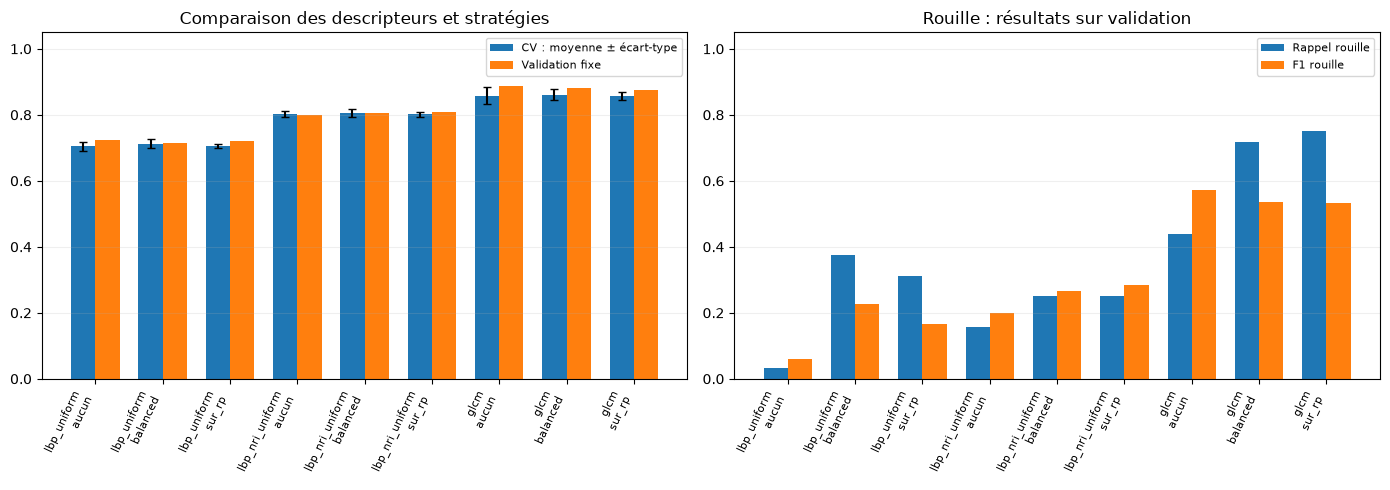

In [7]:
def rang_cv(r):
    return (-r["moyenne_f1_macro"],r["ecart_type_f1"],r["params"]["C"])
retenus = []
for desc in DESCRIPTEURS:
    for strategie in STRATEGIES:
        groupe = [r for r in resultats_cv if r["descripteur"]==desc and r["strategie"]==strategie]
        retenus.append(min(groupe,key=rang_cv))
choix = min([r for r in retenus if r["descripteur"].startswith("lbp_")],key=rang_cv)
cle_choix = (choix["descripteur"],choix["strategie"])
ecrire_json(SORTIE / "choix_avant_test.json", choix)
modeles = {}
validations, details_classes = [], []
for r in retenus:
    desc,strat = r["descripteur"],r["strategie"]
    mdl = entrainer(features[desc][idx_train],y[idx_train],strat,r["params"],GRAINE)
    modeles[(desc,strat)] = mdl
    pred = mdl.predict(features[desc][idx_val])
    m = mesures_prediction(y[idx_val],pred)
    validations.append({"descripteur":desc,"strategie":strat,
        "f1_cv":r["moyenne_f1_macro"],"ecart_type_cv":r["ecart_type_f1"],
        **{f"validation_{k}":v for k,v in m.items()},"params":r["params"],
        "modele_principal":(desc,strat)==cle_choix})
    rep = classification_report(y[idx_val],pred,labels=CLASSES,output_dict=True,zero_division=0)
    for c in CLASSES:
        details_classes.append({"descripteur":desc,"strategie":strat,"classe":c,**rep[c]})
    pd.DataFrame({"image":chemins[idx_val],"reelle":y[idx_val],"predite":pred}).to_csv(
        SORTIE / f"validation_predictions_{desc}_{strat}.csv",index=False)
    joblib.dump(mdl,SORTIE / f"candidat_{desc}_{strat}.joblib")
comparaison = pd.DataFrame(validations)
comparaison.to_csv(SORTIE / "comparaison_validation.csv",index=False)
pd.DataFrame(details_classes).to_csv(SORTIE / "validation_par_classe.csv",index=False)
display(comparaison)
DESCRIPTEUR_RETENU = choix["descripteur"]
modele = modeles[cle_choix]
print("Modèle principal fixé par validation croisée :",cle_choix,choix["params"])
print("Validation :",comparaison.loc[comparaison.modele_principal,"validation_f1_macro"].iloc[0])

# Montrer les effectifs réellement utilisés pour entraîner chaque stratégie.
effectifs_strategies = pd.DataFrame({s:pd.Series(Counter(y[idx_train][
    indices_apprentissage(y[idx_train],s,GRAINE)])) for s in STRATEGIES}).reindex(CLASSES)
display(effectifs_strategies)
effectifs_strategies.to_csv(SORTIE / "effectifs_apprentissage_strategies.csv")

fig,axes = plt.subplots(1,2,figsize=(14,5))
etiquettes = [f"{r.descripteur}\n{r.strategie}" for r in comparaison.itertuples()]
x = np.arange(len(comparaison))
axes[0].bar(x-.18,comparaison.f1_cv,.36,yerr=comparaison.ecart_type_cv,capsize=3,label="CV : moyenne ± écart-type")
axes[0].bar(x+.18,comparaison.validation_f1_macro,.36,label="Validation fixe")
axes[1].bar(x-.18,comparaison.validation_rappel_rp,.36,label="Rappel rouille")
axes[1].bar(x+.18,comparaison.validation_f1_rp,.36,label="F1 rouille")
for ax in axes:
    ax.set_xticks(x); ax.set_xticklabels(etiquettes,rotation=65,ha="right",fontsize=8)
    ax.set_ylim(0,1.05); ax.legend(fontsize=8); ax.grid(axis="y",alpha=.2)
axes[0].set_title("Comparaison des descripteurs et stratégies")
axes[1].set_title("Rouille : résultats sur validation")
fig.tight_layout();fig.savefig(SORTIE / "comparaison_descripteurs.jpeg",dpi=180,bbox_inches="tight")
plt.show()


## 8. Évaluation du modèle LBP retenu et analyse des erreurs
Le test déjà consulté est utilisé ici pour décrire le modèle fixé à la section précédente. Les images de test ne servent pas à choisir le descripteur, la pondération ou les paramètres. Le nombre d’erreurs vers chaque classe est exporté, sans déduire automatiquement leur cause.


Résultats sur le test réutilisé : {'accuracy': 0.9009695290858726, 'balanced_accuracy': 0.8171814062051187, 'f1_macro': 0.8209638053312265, 'rappel_rp': 0.20512820512820512, 'f1_rp': 0.2318840579710145}
                                 precision    recall  f1-score   support

        Fissures en réseau (cr)     0.9077    0.9752    0.9402       242
                   Cavités (gg)     0.8727    0.8136    0.8421        59
                Inclusions (in)     0.9141    0.9613    0.9371       155
Plaques et taches étendues (pa)     0.8789    0.8559    0.8673       229
            Surface piquée (ps)     0.8861    0.8805    0.8833       159
                   Rouille (rp)     0.2667    0.2051    0.2319        39
        Calamine incrustée (rs)     1.0000    1.0000    1.0000       318
                   Rayures (sc)     0.9020    0.8903    0.8961       155
            Taches d’huile (sp)     0.8095    0.7727    0.7907        88

                       accuracy                         0.9010   

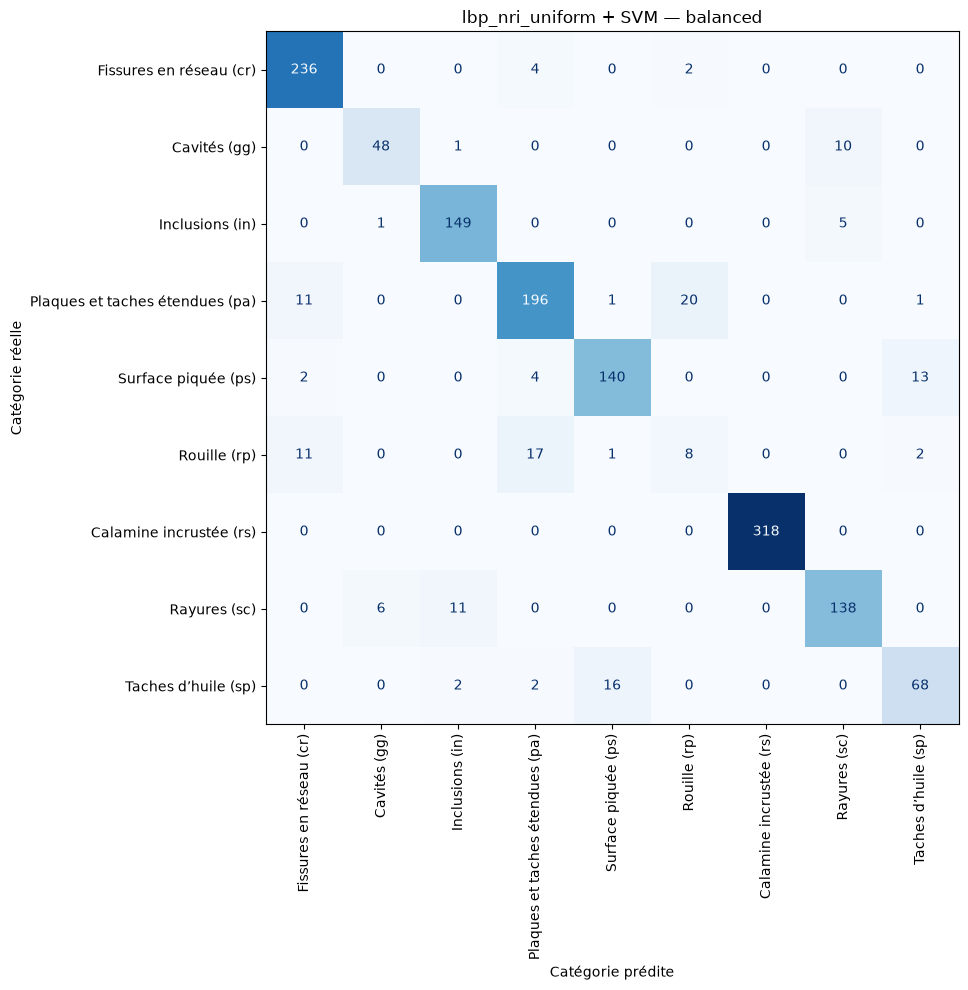

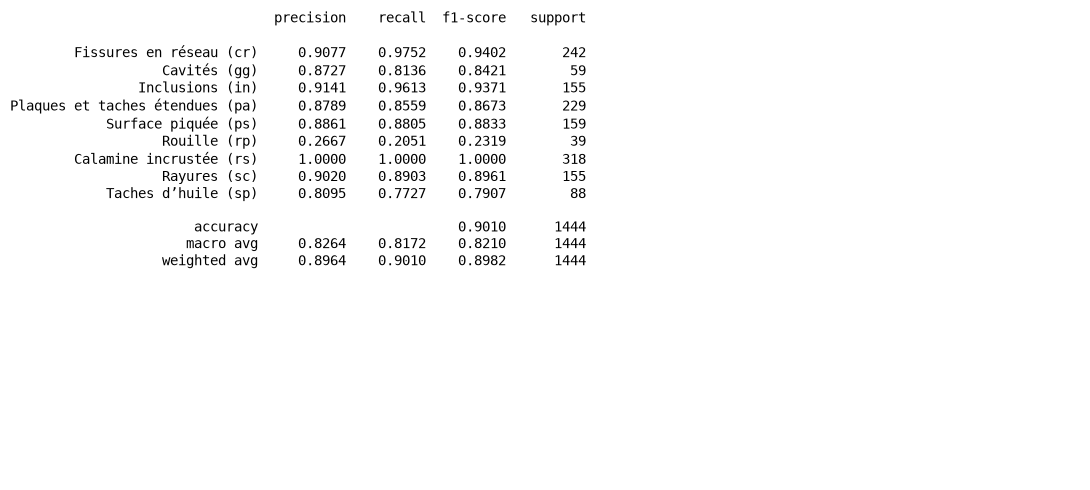

Fissures en réseau (cr) : 236/242 ; erreurs : Plaques et taches étendues (pa) : 4, Rouille (rp) : 2
Cavités (gg) : 48/59 ; erreurs : Rayures (sc) : 10, Inclusions (in) : 1
Inclusions (in) : 149/155 ; erreurs : Rayures (sc) : 5, Cavités (gg) : 1
Plaques et taches étendues (pa) : 196/229 ; erreurs : Rouille (rp) : 20, Fissures en réseau (cr) : 11, Surface piquée (ps) : 1, Taches d’huile (sp) : 1
Surface piquée (ps) : 140/159 ; erreurs : Taches d’huile (sp) : 13, Plaques et taches étendues (pa) : 4, Fissures en réseau (cr) : 2
Rouille (rp) : 8/39 ; erreurs : Plaques et taches étendues (pa) : 17, Fissures en réseau (cr) : 11, Taches d’huile (sp) : 2, Surface piquée (ps) : 1
Calamine incrustée (rs) : 318/318 ; erreurs : aucune
Rayures (sc) : 138/155 ; erreurs : Inclusions (in) : 11, Cavités (gg) : 6
Taches d’huile (sp) : 68/88 ; erreurs : Surface piquée (ps) : 16, Inclusions (in) : 2, Plaques et taches étendues (pa) : 2


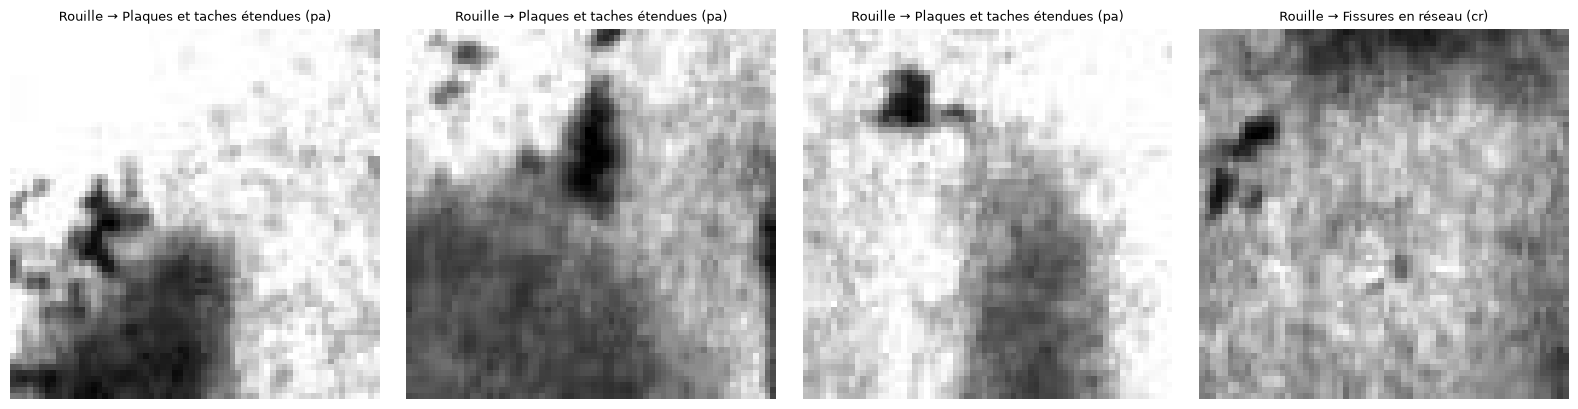

In [8]:
y_test = y[idx_test]
y_pred = modele.predict(features[DESCRIPTEUR_RETENU][idx_test])
mesures = mesures_prediction(y_test,y_pred)
print("Résultats sur le test réutilisé :",mesures)
rapport = classification_report(y_test,y_pred,labels=CLASSES,
    target_names=[nom_classe(c) for c in CLASSES],digits=4,zero_division=0)
print(rapport)
(SORTIE / "rapport_classification.txt").write_text(rapport,encoding="utf-8")
rep_dict = classification_report(y_test,y_pred,labels=CLASSES,output_dict=True,zero_division=0)
pd.DataFrame(rep_dict).T.to_csv(SORTIE / "rapport_classification.csv")
matrice = confusion_matrix(y_test,y_pred,labels=CLASSES)
pd.DataFrame(matrice,index=CLASSES,columns=CLASSES).to_csv(SORTIE / "matrice_confusion.csv")
pd.DataFrame({"image":chemins[idx_test],"empreinte":empreintes_images[idx_test],
    "reelle":y_test,"predite":y_pred}).to_csv(SORTIE / "predictions_test.csv",index=False)
fig,ax=plt.subplots(figsize=(11,10))
ConfusionMatrixDisplay(matrice,display_labels=[nom_classe(c) for c in CLASSES]).plot(
    ax=ax,cmap="Blues",colorbar=False,xticks_rotation=90)
ax.set_xlabel("Catégorie prédite");ax.set_ylabel("Catégorie réelle")
ax.set_title(f"{DESCRIPTEUR_RETENU} + SVM — {choix['strategie']}")
fig.tight_layout();fig.savefig(SORTIE / "matrice_confusion_svm.jpeg",dpi=180,bbox_inches="tight")
plt.show()

fig,ax=plt.subplots(figsize=(11,5));ax.axis("off")
ax.text(0,1,rapport,va="top",family="monospace",fontsize=10)
fig.tight_layout();fig.savefig(SORTIE / "rapport_classification_svm.jpeg",dpi=180,bbox_inches="tight")
plt.show()

erreurs=[]
for i,c in enumerate(CLASSES):
    total=int(matrice[i].sum()); correct=int(matrice[i,i])
    destinations=sorted([(CLASSES[j],int(matrice[i,j])) for j in range(len(CLASSES))
                         if j!=i and matrice[i,j]],key=lambda t:-t[1])
    print(f"{nom_classe(c)} : {correct}/{total} ; erreurs : " +
          (", ".join(f"{nom_classe(d)} : {n}" for d,n in destinations) or "aucune"))
    for d,n in destinations:
        erreurs.append({"reelle":c,"predite":d,"nombre":n,"proportion_classe":n/total})
pd.DataFrame(erreurs).to_csv(SORTIE / "erreurs_par_classe.csv",index=False)
# Afficher au plus quatre erreurs de rouille, sans modifier ensuite le choix du modèle.
positions=np.flatnonzero((y_test=="rp") & (y_pred!="rp"))[:4]
if len(positions):
    fig,axes=plt.subplots(1,len(positions),figsize=(4*len(positions),4),squeeze=False)
    for ax,j in zip(axes.ravel(),positions):
        ax.imshow(lire_gris(chemins[idx_test[j]]),cmap="gray")
        ax.set_title(f"Rouille → {nom_classe(y_pred[j])}",fontsize=9);ax.axis("off")
    fig.tight_layout();fig.savefig(SORTIE / "erreurs_rouille.jpeg",dpi=180,bbox_inches="tight")
    plt.show()


## 9. Sauvegarde complète
Le fichier joblib contient un pipeline standard scikit-learn, le descripteur retenu et ses paramètres. Aucun estimateur personnalisé ni imbalanced-learn n’est requis au rechargement. Les résultats sont calculés pendant ton exécution : aucun ancien score n’est présenté comme un nouveau résultat.


In [9]:
artefact = {"modele":modele,"descripteur":DESCRIPTEUR_RETENU,
    "strategie":choix["strategie"],"parametres":choix["params"],
    "P":P,"R":R,"bord_exclu":R,"dimensions":DESCRIPTEURS[DESCRIPTEUR_RETENU],
    "noms_classes":NOMS_CLASSES,"pretraitement":"Pillow L uint8 ; sans redimensionnement",
    "versions":VERSIONS,"signature_corpus":signature_corpus,
    "graine":GRAINE,"selection":"F1 macro moyen de cinq plis sur train, candidats LBP uniquement"}
joblib.dump(artefact,SORTIE / "modele_final.joblib")
resume = {"date":datetime.now().isoformat(),"python":sys.version,
    "configuration":configuration,"choix":choix,"test":mesures,
    "validation_modele_retenu":comparaison.loc[comparaison.modele_principal].iloc[0].to_dict(),
    "effectifs":{k:len(v) for k,v in PARTITIONS.items()},
    "doublons_ecartes":len(doublons_details),
    "limites":["Test déjà consulté avant cette expérience",
               "Quasi-doublons et groupes de provenance non identifiés",
               "Suréchantillonnage : répétitions, pas de nouvelles observations",
               "Pas de garantie d’optimalité globale ni de significativité des écarts"]}
ecrire_json(SORTIE / "resultats.json",resume)
# Vérification du rechargement sur quelques exemples, sans réentraînement.
recharge = joblib.load(SORTIE / "modele_final.joblib")
assert np.array_equal(recharge["modele"].predict(features[DESCRIPTEUR_RETENU][idx_test[:5]]),y_pred[:5])
print("Modèle sauvegardé et rechargement vérifié.")
print("Résultats :",SORTIE)


Modèle sauvegardé et rechargement vérifié.
Résultats : C:\Master_2\RDF\resultats_TP_ameliore\ec9b9475e81786a1


## 10. Démonstration avec le modèle sauvegardé
Seules les images du dossier test de cette expérience sont acceptées. Le chemin et l’empreinte des pixels sont vérifiés. La fonction utilise les paramètres du fichier sauvegardé, y compris la variante LBP sélectionnée.


Réelle : Surface piquée (ps)
Prédite : Surface piquée (ps)
Résultat : Correct


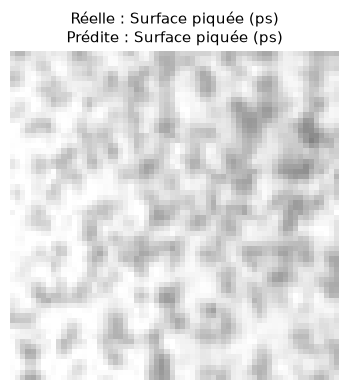

Réelle : Fissures en réseau (cr)
Prédite : Fissures en réseau (cr)
Résultat : Correct


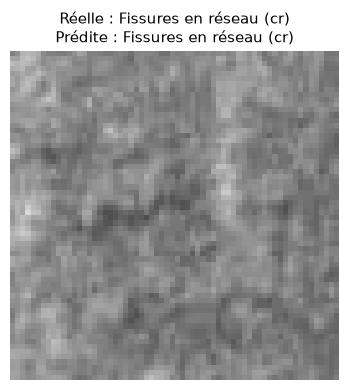

'cr'

In [15]:
AUTORISES = {Path(chemins[i]).resolve():i for i in idx_test}
def demonstration(chemin):
    p = Path(chemin).resolve()
    if p not in AUTORISES:
        raise ValueError(f"Choisir une image dans {DOSSIER_SPLIT / 'test'}")
    i=AUTORISES[p]
    a=lire_gris(p)
    if empreinte_pixels(a)!=empreintes_images[i]:
        raise ValueError("Image modifiée depuis la séparation.")
    paquet=joblib.load(SORTIE / "modele_final.joblib")
    if paquet["P"]!=P or paquet["R"]!=R:
        raise ValueError("Paramètres d’extraction modifiés : réexécuter le notebook dans l’ordre.")
    v=extraire_image(a,paquet["descripteur"])
    prediction=str(paquet["modele"].predict(v.reshape(1,-1))[0])
    print("Réelle :",nom_classe(y[i]))
    print("Prédite :",nom_classe(prediction))
    print("Résultat :","Correct" if prediction==y[i] else "Incorrect")
    fig,ax=plt.subplots(figsize=(6,4))
    ax.imshow(a,cmap="gray",vmin=0,vmax=255);ax.axis("off")
    ax.set_title(f"Réelle : {nom_classe(y[i])}\nPrédite : {nom_classe(prediction)}",fontsize=11)
    fig.tight_layout();fig.savefig(SORTIE / "demonstration_svm.jpeg",dpi=180,bbox_inches="tight")
    plt.show()
    return prediction

_ = demonstration(chemins[idx_test[0]])

def choisir_image():
    import tkinter as tk
    from tkinter import filedialog
    fenetre=tk.Tk();fenetre.withdraw();fenetre.attributes("-topmost",True)
    try:
        choix_image=filedialog.askopenfilename(parent=fenetre,title="Choisir une image du test",
            initialdir=str(DOSSIER_SPLIT / "test"),
            filetypes=[("Images","*.jpg *.jpeg *.png *.bmp *.tif *.tiff")])
    finally:
        fenetre.destroy()
    if choix_image:
        return demonstration(choix_image)
    print("Sélection annulée.")

# Pour ouvrir la fenêtre, retirer le # de la ligne suivante et exécuter cette cellule :
choisir_image()


Réelle : Rouille (rp)
Prédite : Plaques et taches étendues (pa)
Résultat : Incorrect


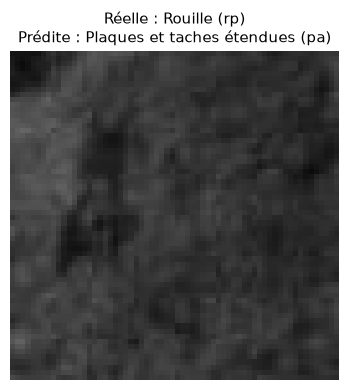

'pa'

In [16]:
def choisir_image():
    import tkinter as tk
    from tkinter import filedialog
    fenetre=tk.Tk();fenetre.withdraw();fenetre.attributes("-topmost",True)
    try:
        choix_image=filedialog.askopenfilename(parent=fenetre,title="Choisir une image du test",
            initialdir=str(DOSSIER_SPLIT / "test"),
            filetypes=[("Images","*.jpg *.jpeg *.png *.bmp *.tif *.tiff")])
    finally:
        fenetre.destroy()
    if choix_image:
        return demonstration(choix_image)
    print("Sélection annulée.")

# Pour ouvrir la fenêtre, retirer le # de la ligne suivante et exécuter cette cellule :
choisir_image()

## 11. Lecture des résultats et sources

Après l’exécution, utiliser `comparaison_validation.csv` pour comparer les neuf candidats, notamment le rappel et le F1 de la rouille. Une hausse du rappel accompagnée d’une forte baisse de précision signifie davantage de fausses alertes. Le F1-macro permet de suivre l’ensemble des neuf classes. Les écarts-types des cinq plis ne sont pas des intervalles de confiance.

Un gain de la variante à 59 fréquences indique qu’elle fonctionne mieux dans ce protocole, sans prouver à lui seul que l’orientation explique ce gain. La comparaison GLCM porte sur cinq propriétés et une configuration précise, pas sur toutes les variantes possibles de cette famille. Les résultats du modèle initial restent ceux d’une expérience antérieure.

Les noms français correspondent aux catégories présentées dans l’article décrivant NEU-CLS-64 : `gg` = pits (cavités), `rp` = rust (rouille), `sp` = oil stains (taches d’huile). Cet article est cité pour le corpus ; son réseau de neurones n’est pas utilisé.

- [Guo, Gong et Lu, description de NEU-CLS-64, Coatings, 2023](https://www.mdpi.com/2079-6412/13/12/2015).
- [scikit-image : LBP et propriétés GLCM](https://scikit-image.org/docs/stable/api/skimage.feature.html).
- [scikit-learn : validation croisée](https://scikit-learn.org/stable/modules/cross_validation.html).
- [Rééchantillonnage et fuite de données](https://imbalanced-learn.org/stable/common_pitfalls.html).
- [Dépôt du groupe](https://github.com/MTD-MTD/TP_RDF).
